# Prioritizing isolate-only clusters for antibiotic discovery

- Input: `analysis_output/nodes_isolate_only.tsv` and `edges_isolate_only.tsv`.
- Dataset: nodes detected in isolates and absent from marine-broth blank.
- Aim: rank molecular families by likelihood of containing novel antibacterial chemistry.
- Output: a prioritized shortlist for follow-up (not confirmed antibiotics).
- Note: MS/MS similarity is not proof of bioactivity. Wet-lab assays are required.

- This notebook highlights families with the strongest network-level evidence for isolate-restricted secondary metabolism based on solely the GNPS2 data. It does not prove antibacterial activity. Wet-lab assays would be required.

- To do:
    - Manually inspect MS/MS spectra for chemical sense and artifacts.
    - Run broader dereplication and in-silico annotation (maybe SIRIUS, CSI:FingerID, NPClassifier, etc.).
    - Confirm isotope patterns and adduct/charge assignments for hub masses.
    - Use bioassay-guided fractionation to link mass to activity.
    - Treat the taxonomic prior as a soft guide (not a filter)
    - Re-run scoring with alternative `WEIGHTS` if your priorities change? (e.g., remove `producer_score` or upweight `mass_score`).

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

OUT_DIR = Path("results/msms_analysis_output")   # run this notebook from the repo root
nodes = pd.read_csv(OUT_DIR / "nodes_isolate_only.tsv", sep="\t", low_memory=False)
edges = pd.read_csv(OUT_DIR / "edges_isolate_only.tsv", sep="\t")
nodes["RTMean_min"] = nodes["RTMean"] / 60   # GNPS2 reports RTMean in seconds despite the "(Min)" label

ISOLATE_COLS = [c for c in nodes.columns
                if c.startswith("ATTRIBUTE_ORGANISM:GNPSGROUP:") and c != "ATTRIBUTE_ORGANISM:GNPSGROUP:nan"]
ISOLATE_LABELS = [c.split(":")[-1] for c in ISOLATE_COLS]
GENUS_OF = {label: label.split("_")[0] for label in ISOLATE_LABELS}

print(f"Nodes: {len(nodes)}   Edges: {len(edges)}")
print(f"Isolates ({len(ISOLATE_LABELS)}): {ISOLATE_LABELS}")

## 1. What makes a cluster interesting for antibiotic discovery?

- 5 heuristics from natural-product discovery pipelines:
- 1) Family size: many nodes → diversified analog series. Strong signal for BGC-driven chemistry.
- 2) Novelty: lack of clean library matches increases discovery potential.
- 3) Taxonomic priors: some genera (e.g. Phaeobacter, Roseovarius, Vibrio) are more likely to produce antibacterials. This is a soft prior.
- 4) Mass plausibility: typical antibiotic masses are ~300–1500 Da. Very small masses are deprioritized.
- 5) Isolate specificity: families found in few isolates (1–3) are likelier to be strain-specific secondary metabolites.
- Multi-node families are scored on these axes; singletons are handled separately later

## 2. Per-node annotations needed for scoring

- Compute per-node fields required for family scoring (isolate counts, valid library hits, etc.).

In [ ]:
presence = nodes[ISOLATE_COLS] > 0
nodes["n_isolates_present"] = presence.sum(axis=1)
nodes["isolates_present"] = presence.apply(lambda r: [ISOLATE_LABELS[i] for i, v in enumerate(r) if v], axis=1)

# Flags are informational only (kept as columns, never used to drop rows).
# 300 ppm sits in this dataset's natural gap between real matches (<~50 ppm)
# and clearly-wrong ones (>~300 ppm), so plausible analogue/adduct hits aren't flagged.
# A flagged hit still counts as "not a valid_hit" for novelty scoring below, since
# an unreliable match shouldn't suppress a cluster's novelty.
PPM_FLAG_LIMIT = 300

has_match = nodes["Compound_Name"].notna() & (nodes["Compound_Name"] != "")
nodes["flag_ion_mobility"] = has_match & nodes.get("LibraryName", pd.Series("", index=nodes.index)).str.contains("ION-MOBILITY", na=False)
nodes["flag_high_ppm"] = has_match & (nodes["MZErrorPPM"].abs() > PPM_FLAG_LIMIT)
flagged = nodes["flag_ion_mobility"] | nodes["flag_high_ppm"]
nodes["valid_hit"] = has_match & ~flagged

print(f"Nodes with >=1 valid library hit: {nodes['valid_hit'].sum()} / {len(nodes)}")
print(f"  - flagged for ion-mobility source: {nodes['flag_ion_mobility'].sum()}")
print(f"  - flagged for mass error > {PPM_FLAG_LIMIT} ppm: {nodes['flag_high_ppm'].sum()}")
nodes[["cluster index", "n_isolates_present", "parent mass", "valid_hit", "flag_ion_mobility", "flag_high_ppm"]].head()

## 3. Build the network and aggregate to molecular-family level

- Build the graph and identify connected components (families).
- For each family, compute size, isolates involved, mass range, and library-hit coverage.
- These family-level metrics feed into the scoring in Step 4.

In [3]:
G = nx.Graph()
G.add_nodes_from(nodes["cluster index"])
for _, row in edges.iterrows():
    G.add_edge(row["CLUSTERID1"], row["CLUSTERID2"], cosine=row["Cosine"], delta_mz=row["DeltaMZ"])

node_idx = nodes.set_index("cluster index")
components = [c for c in nx.connected_components(G) if len(c) >= 2]
singletons = [list(c)[0] for c in nx.connected_components(G) if len(c) == 1]
print(f"Multi-node families: {len(components)}   Singleton features: {len(singletons)}")

PRODUCER_GENERA = {"Phaeobacter", "Roseovarius", "Vibrio"}

def mass_plausibility(m):
    """0-1 score peaking across the typical NRP/PKS antibiotic mass window."""
    if m < 100:
        return 0.0
    if m < 300:
        return (m - 100) / 200
    if m <= 1500:
        return 1.0
    if m <= 2500:
        return max(0.0, 1 - (m - 1500) / 1000)
    return 0.0

records = []
for comp in components:
    sub = node_idx.loc[list(comp)]
    isolates_involved = sorted(set(iso for lst in sub["isolates_present"] for iso in lst))
    genera_involved = {GENUS_OF[i] for i in isolates_involved}
    hub = max(comp, key=lambda n: G.degree[n])  # highest-degree node = structural anchor of the family
    valid_members = sub[sub["valid_hit"]]
    records.append({
        "component_hub": hub,
        "size": len(comp),
        "n_edges": G.subgraph(comp).number_of_edges(),
        "mass_mean": sub["parent mass"].mean(),
        "mass_min": sub["parent mass"].min(),
        "mass_max": sub["parent mass"].max(),
        "isolates_involved": isolates_involved,
        "genera_involved": sorted(genera_involved),
        "has_producer_genus": bool(genera_involved & PRODUCER_GENERA),
        "pct_private": (sub["n_isolates_present"] == 1).mean(),
        "n_valid_hits": len(valid_members),
        "novelty": 1 - len(valid_members) / len(comp),
        "compound_names": "; ".join(valid_members["Compound_Name"].dropna().unique()[:3]),
        "npclassifier_pathway": "; ".join(valid_members["npclassifier_pathway"].dropna().unique()),
        "members": sorted(comp),
    })

fam = pd.DataFrame(records)
fam.head()

Multi-node families: 57   Singleton features: 199


,component_hub,size,n_edges,mass_mean,mass_min,mass_max,isolates_involved,genera_involved,has_producer_genus,pct_private,n_valid_hits,novelty,compound_names,npclassifier_pathway,members
0,1.0,3,2,103.725834,103.053967,105.069565,"[Acinetobacter_D3M06, Arenibacter_D3M17, Colwe...","[Acinetobacter, Arenibacter, Colwellia, Paraco...",True,0.333333,0,1.000000,,,"[1, 2.0, 3.0]"
1,72.0,3,2,125.619534,113.963189,131.929251,"[Acinetobacter_D3M06, Arenibacter_D3M17, Colwe...","[Acinetobacter, Arenibacter, Colwellia, Motili...",True,0.000000,0,1.000000,,,"[7, 67.0, 72.0]"
2,76.0,13,15,131.469950,116.070229,166.086084,"[Acinetobacter_D3M06, Arenibacter_D3M17, Colwe...","[Acinetobacter, Arenibacter, Colwellia, Motili...",True,0.461538,1,0.923077,Spectral Match to DL-Phenylalanine from NIST14,Amino acids and Peptides|Shikimates and Phenyl...,"[8, 25.0, 52.0, 54.0, 62.0, 63.0, 64.0, 76.0, ..."
3,9.0,2,1,116.070229,116.070229,116.070229,[Arenibacter_D3M17],[Arenibacter],False,1.000000,0,1.000000,,,"[9, 10.0]"
4,12.0,9,10,227.171816,117.072799,346.277022,"[Acinetobacter_D3M06, Arenibacter_D3M17, Colwe...","[Acinetobacter, Arenibacter, Colwellia, Motili...",True,0.000000,0,1.000000,,,"[12, 15.0, 16.0, 17.0, 262.0, 268.0, 295.0, 29..."


## 4. Score and rank the families

- Convert each heuristic into a 0–1 sub-score.
- Combine sub-scores into a weighted composite score.
- Default weights favor family size and novelty; taxonomy and specificity are softer priors.

In [4]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else s * 0

fam["size_score"] = minmax(np.log2(fam["size"] + 1))
fam["novelty_score"] = fam["novelty"]                       # already 0-1
fam["producer_score"] = fam["has_producer_genus"].astype(float)
fam["mass_score"] = fam["mass_mean"].apply(mass_plausibility)
fam["specificity_score"] = fam["pct_private"]               # already 0-1

WEIGHTS = {
    "size_score": 0.30,
    "novelty_score": 0.25,
    "producer_score": 0.20,
    "mass_score": 0.15,
    "specificity_score": 0.10,
}
fam["composite_score"] = sum(fam[k] * w for k, w in WEIGHTS.items())

print("Weights:", WEIGHTS, "(sum =", sum(WEIGHTS.values()), ")")
fam[["component_hub", "size", "size_score", "novelty_score", "producer_score",
     "mass_score", "specificity_score", "composite_score"]].sort_values("composite_score", ascending=False).head(10)

Weights: {'size_score': 0.3, 'novelty_score': 0.25, 'producer_score': 0.2, 'mass_score': 0.15, 'specificity_score': 0.1} (sum = 1.0 )


,component_hub,size,size_score,novelty_score,producer_score,mass_score,specificity_score,composite_score
35,431.0,21,1.000000,1.000000,1.0,1.000000,0.142857,0.914286
40,466.0,16,0.870596,1.000000,1.0,1.000000,0.125000,0.873679
37,494.0,10,0.652110,1.000000,1.0,1.000000,0.400000,0.835633
33,576.0,11,0.695781,1.000000,1.0,1.000000,0.181818,0.826916
29,280.0,4,0.256383,1.000000,1.0,1.000000,1.000000,0.776915
13,182.0,8,0.551393,1.000000,1.0,0.361198,0.875000,0.757098
53,651.0,5,0.347890,1.000000,1.0,1.000000,0.400000,0.744367
55,659.0,5,0.347890,1.000000,1.0,1.000000,0.400000,0.744367
46,616.0,3,0.144388,1.000000,1.0,1.000000,1.000000,0.743316
2,76.0,13,0.773149,0.923077,1.0,0.157350,0.461538,0.732470


## 5. Identify best candidates for follow-up

- top 15 families by composite score.
- Provide isolates, mass range, library hits, size, and novelty.

In [5]:
top = fam.sort_values("composite_score", ascending=False).head(15).reset_index(drop=True)
display_cols = ["component_hub", "size", "mass_mean", "mass_min", "mass_max",
                 "isolates_involved", "genera_involved", "pct_private", "n_valid_hits",
                 "compound_names", "npclassifier_pathway", "composite_score"]
top[display_cols].round(3)

,component_hub,size,mass_mean,mass_min,mass_max,isolates_involved,genera_involved,pct_private,n_valid_hits,compound_names,npclassifier_pathway,composite_score
0,431.0,21,507.785,393.209,665.444,"[Acinetobacter_D3M06, Arenibacter_D3M17, Colwe...","[Acinetobacter, Arenibacter, Colwellia, Paraco...",0.143,0,,,0.914
1,466.0,16,601.935,470.332,746.524,"[Acinetobacter_D3M06, Arenibacter_D3M17, Colwe...","[Acinetobacter, Arenibacter, Colwellia, Paraco...",0.125,0,,,0.874
2,494.0,10,549.292,442.264,654.350,"[Acinetobacter_D3M06, Arenibacter_D3M17, Colwe...","[Acinetobacter, Arenibacter, Colwellia, Motili...",0.400,0,,,0.836
3,576.0,11,550.248,359.290,671.303,"[Acinetobacter_D3M06, Arenibacter_D3M17, Colwe...","[Acinetobacter, Arenibacter, Colwellia, Paraco...",0.182,0,,,0.827
4,280.0,4,372.293,304.213,416.337,"[Paracoccus_C2R07, Phaeobacter_B2R04]","[Paracoccus, Phaeobacter]",1.000,0,,,0.777
5,182.0,8,172.240,156.102,188.129,"[Acinetobacter_D3M06, Arenibacter_D3M17, Colwe...","[Acinetobacter, Arenibacter, Colwellia, Paraco...",0.875,0,,,0.757
6,651.0,5,898.427,806.401,934.459,"[Acinetobacter_D3M06, Arenibacter_D3M17, Parac...","[Acinetobacter, Arenibacter, Paracoccus, Phaeo...",0.400,0,,,0.744
7,659.0,5,975.500,835.441,1177.580,"[Acinetobacter_D3M06, Arenibacter_D3M17, Colwe...","[Acinetobacter, Arenibacter, Colwellia, Paraco...",0.400,0,,,0.744
8,616.0,3,722.026,619.317,773.381,"[Vibrio_1A01, Vibrio_6D03]",[Vibrio],1.000,0,,,0.743
9,76.0,13,131.470,116.070,166.086,"[Acinetobacter_D3M06, Arenibacter_D3M17, Colwe...","[Acinetobacter, Arenibacter, Colwellia, Motili...",0.462,1,Spectral Match to DL-Phenylalanine from NIST14,Amino acids and Peptides|Shikimates and Phenyl...,0.732


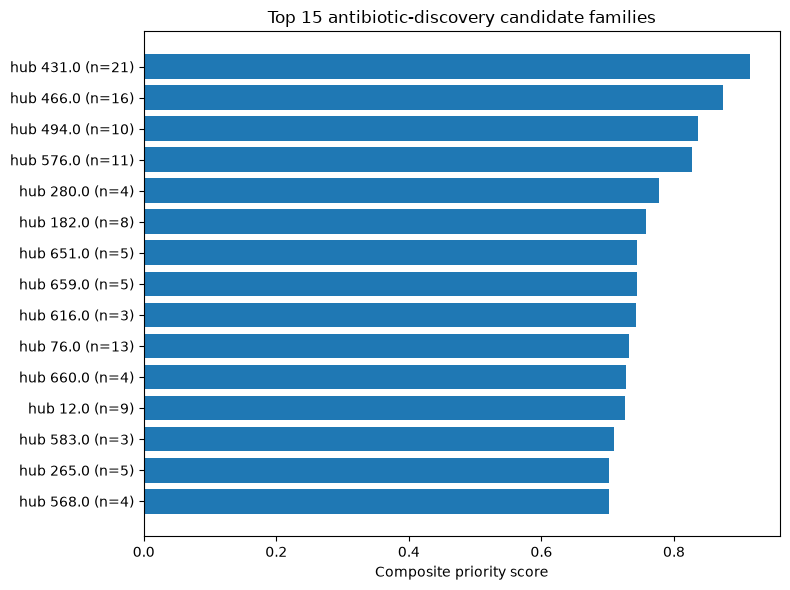

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
labels = [f"hub {h} (n={s})" for h, s in zip(top["component_hub"], top["size"])]
ax.barh(labels[::-1], top["composite_score"][::-1], color="#1f78b4")
ax.set_xlabel("Composite priority score")
ax.set_title("Top 15 antibiotic-discovery candidate families")
plt.tight_layout()
plt.show()

## 6. Novel singletons (no analogs detected, but still worth a look)

- Lack family-size evidence but may still be good discovery targets?
- Flag singletons that are high-mass, isolate-private, and unannotated.

In [7]:
single_df = node_idx.loc[singletons].copy()
single_df["mass_score"] = single_df["parent mass"].apply(mass_plausibility)
single_df["is_private"] = single_df["n_isolates_present"] == 1
single_df["dominant_isolate"] = single_df["isolates_present"].apply(lambda l: l[0] if len(l) == 1 else "|".join(l))

novel_singletons = single_df[(~single_df["valid_hit"]) & single_df["is_private"] & (single_df["mass_score"] > 0.5)]
novel_singletons = novel_singletons.sort_values("parent mass", ascending=False)

print(f"Novel, isolate-private, mass-plausible singletons: {len(novel_singletons)} / {len(singletons)} total singletons")
novel_singletons.reset_index()[["cluster index", "parent mass", "RTMean_min", "dominant_isolate", "number of spectra"]].head(15)

Novel, isolate-private, mass-plausible singletons: 61 / 199 total singletons


,cluster index,parent mass,RTMean_min,dominant_isolate,number of spectra
0,688,1161.549377,6.874125,Colwellia_C2M19,2
1,658,934.458618,6.900267,Shewanella_B2R08,3
2,646,891.588806,0.329860,Vibrio_6D03,6
3,643,879.478373,6.745367,Vibrio_1A01,2
4,624,806.400513,6.938575,Shewanella_B2R08,2
5,622,795.408752,6.887300,Vibrio_6D03,2
6,612,766.382528,6.830594,Vibrio_6D03,3
7,606,751.370585,4.307908,Salipiger_C3M06,2
8,599,741.572500,0.330119,Vibrio_6D03,12
9,581,679.302877,6.856542,Arenibacter_D3M17,2


## 7. Visualization of top candidate families

- Plot subnetworks for top candidates to inspect coherence.
- Look for tight linking and plausible mass-difference patterns.
- Loose or noisy groupings may be lower-priority artifacts.

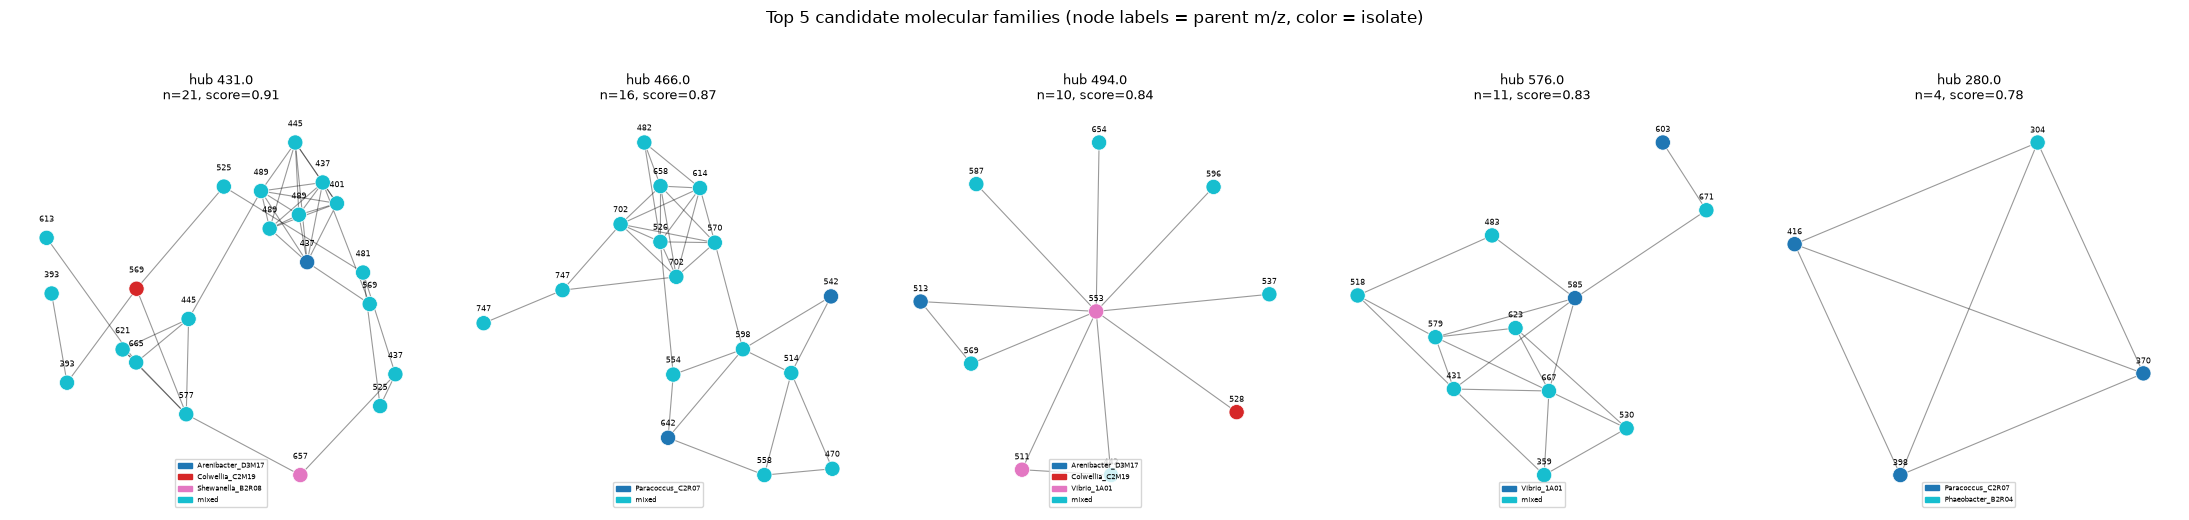

In [8]:
top5 = top.head(5)
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, (_, fam_row) in zip(axes, top5.iterrows()):
    members = fam_row["members"]
    H = G.subgraph(members)
    pos = nx.spring_layout(H, seed=42, k=0.8)

    dom_isolate = node_idx.loc[members, "isolates_present"].apply(lambda l: l[0] if len(l) == 1 else "mixed")
    unique_isolates = sorted(dom_isolate.unique())
    palette = plt.cm.tab10(np.linspace(0, 1, max(len(unique_isolates), 1)))
    color_map = dict(zip(unique_isolates, palette))
    node_colors = [color_map[dom_isolate[n]] for n in H.nodes()]

    nx.draw_networkx_edges(H, pos, ax=ax, alpha=0.4, width=0.8)
    nx.draw_networkx_nodes(H, pos, ax=ax, node_size=120, node_color=node_colors, edgecolors="white", linewidths=0.5)

    masses = node_idx.loc[members, "parent mass"]
    for n in H.nodes():
        ax.text(pos[n][0], pos[n][1] + 0.06, f"{masses[n]:.0f}", fontsize=6, ha="center")

    ax.set_title(f"hub {fam_row['component_hub']}\nn={fam_row['size']}, score={fam_row['composite_score']:.2f}", fontsize=9)
    ax.axis("off")
    handles = [mpatches.Patch(color=color_map[iso], label=iso) for iso in unique_isolates]
    ax.legend(handles=handles, fontsize=5, loc="lower center")

plt.suptitle("Top 5 candidate molecular families (node labels = parent m/z, color = isolate)", y=1.03)
plt.tight_layout()
plt.savefig(OUT_DIR / "antibiotic_candidate_families_top5.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. How much does the taxonomic prior actually matter?

- Check whether top candidates are enriched for producer genera.
- Tests if the taxonomic prior materially affects ranking. -> If not, family size and novelty dominate the signal.

Genus representation among top 15 candidate families:
genera_involved
Vibrio           13
Phaeobacter      12
Roseovarius      12
Acinetobacter    11
Arenibacter      11
Paracoccus       11
Salipiger        11
Colwellia        10
Shewanella       10
Motilimonas       6
Name: count, dtype: int64


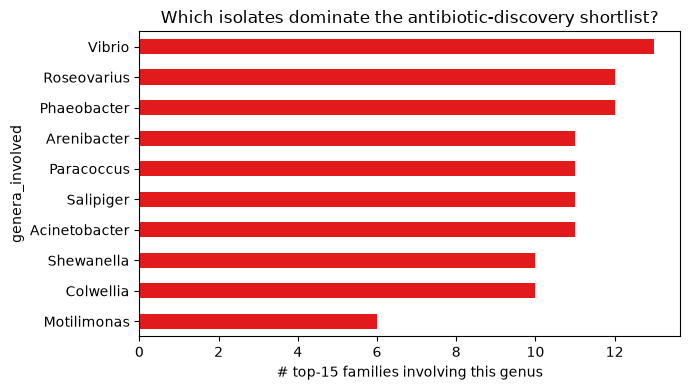

In [9]:
genus_exploded = top.explode("genera_involved")
crosstab = genus_exploded["genera_involved"].value_counts()
print("Genus representation among top 15 candidate families:")
print(crosstab)

fig, ax = plt.subplots(figsize=(7, 4))
crosstab.sort_values().plot(kind="barh", ax=ax, color="#e31a1c")
ax.set_xlabel("# top-15 families involving this genus")
ax.set_title("Which isolates dominate the antibiotic-discovery shortlist?")
plt.tight_layout()
plt.show()

## 9. Export & saving

In [10]:
export_cols = ["component_hub", "size", "mass_mean", "mass_min", "mass_max", "isolates_involved",
               "genera_involved", "has_producer_genus", "pct_private", "n_valid_hits",
               "compound_names", "npclassifier_pathway", "composite_score", "members"]
top[export_cols].to_csv(OUT_DIR / "antibiotic_candidate_families_top15.tsv", sep="\t", index=False)
novel_singletons.reset_index()[["cluster index", "parent mass", "RTMean_min", "dominant_isolate", "number of spectra"]] \
    .to_csv(OUT_DIR / "antibiotic_candidate_singletons.tsv", sep="\t", index=False)
print("Saved -> analysis_output/antibiotic_candidate_families_top15.tsv")
print("Saved -> analysis_output/antibiotic_candidate_singletons.tsv")

Saved -> analysis_output/antibiotic_candidate_families_top15.tsv
Saved -> analysis_output/antibiotic_candidate_singletons.tsv
